In [1]:
from torch_harmonics.spherical_harmonics import SphericalHarmonics

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from torch_harmonics import plotting
import xarray
import torch
from torch import nn

In [3]:
f = xarray.load_dataset('/home/colin/hdd/workspace/datasets/test_dataset.nc')

In [4]:
f['rti'].shape
# Aspect is at 180 (61)

(3000, 61, 21, 107, 2)

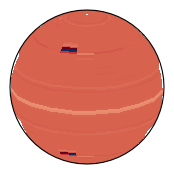

In [5]:
sample = f['rti'][0,:,:,53,0]
y = torch.tensor(sample.to_numpy()).view(1,61,21).repeat(1,2,1)
plotting.plot_spherical_fn(y.squeeze().numpy(), fig=plt.figure(figsize=(2,2)))

frame=0
frame=10
frame=20
frame=30
frame=40
frame=50
frame=60
frame=70
frame=80
frame=90
frame=100


KeyboardInterrupt: 

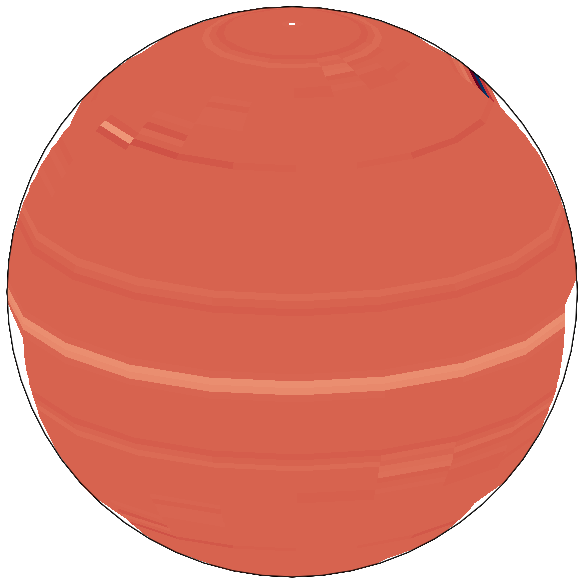

In [9]:
import matplotlib.animation as animation

fig = plt.figure(layout='constrained', figsize=(12, 8), dpi=72)

moviewriter = animation.writers['pillow'](fps=30)
moviewriter.setup(fig, 'radar_2.gif', dpi=72)

num_frames = 360
for frame in range(num_frames):
    # compute the rotation of the sphere
    lon = -num_frames - (360 / num_frames) * frame

    if frame % 10 == 0:
        print(f"frame={frame}")
    
        plotting.plot_spherical_fn(y.squeeze().numpy(), fig=fig, central_longitude=lon)

    plt.draw()
    moviewriter.grab_frame()

moviewriter.finish()

In [77]:
class SHT(nn.Module):
    def __init__(self, L=3, num_theta=61*2, num_phi=21):
        super().__init__()
        self.w_lin = nn.Linear(num_theta*num_phi, (L+1)**2)
        self.sh = SphericalHarmonics(L, num_lat=num_theta, num_lon=num_phi)
        self.mlp_out = nn.Linear(num_theta*num_phi, num_theta*num_phi)

    def forward(self, x):
        w = self.w_lin(x)
        y = self.sh(w).float().view(1, -1)
        y = self.mlp_out(y).view(1,self.sh.num_lat, self.sh.num_lon)
        return y, w.detach()

In [78]:
L = 10
sh_model = SHT(L)
optimizer = torch.optim.Adam(sh_model.parameters(), lr = 1e-4)

for iter in range(200):
    y_pred, _ = sh_model(y.view(1,-1))
    loss = (y_pred - y).pow(2).mean()

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if iter % 10 == 0:
        print(f'iteration: {iter} loss: {loss.item()}')

iteration: 0 loss: 0.1219070553779602
iteration: 10 loss: 0.03855821490287781
iteration: 20 loss: 0.022918036207556725
iteration: 30 loss: 0.00788277667015791
iteration: 40 loss: 0.0005451511824503541
iteration: 50 loss: 0.0010833028936758637
iteration: 60 loss: 5.632037573377602e-05
iteration: 70 loss: 0.00014029539306648076
iteration: 80 loss: 1.128788153437199e-05
iteration: 90 loss: 1.766641071299091e-05
iteration: 100 loss: 1.195866502712306e-06
iteration: 110 loss: 2.3449340460501844e-06
iteration: 120 loss: 1.5574447331800911e-07
iteration: 130 loss: 3.100301739777933e-07
iteration: 140 loss: 1.1851058445699891e-07
iteration: 150 loss: 1.0957018758972481e-07
iteration: 160 loss: 1.9580271271024685e-07
iteration: 170 loss: 1.1916066711137319e-07
iteration: 180 loss: 2.6634870664565824e-07
iteration: 190 loss: 2.699061667499336e-07


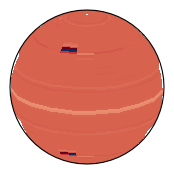

In [79]:
with torch.no_grad():
    pred, w = sh_model(y.view(1,-1))
    plotting.plot_spherical_fn(pred.squeeze().numpy(), fig=plt.figure(figsize=(2,2)))

In [30]:
sorted, idxs = torch.sort(torch.abs(w))

In [59]:
print(idxs[0,-100:].numpy())
sorted[0,-100:].numpy().round(3)

[5167 1029 3748 3897 4055  778 2111  988  360 5425 2325 3715  116 4491
 1693 1006 3418  316 1129 1271 3063 5147 1948 3386 2870 3294 4823 4216
 3637 2715 5485 2596 2660 5371 1501 4932 3152 5022 1311 3245 5598 4900
 1579 4142 2294 4302 3818  927 3043  813 2960 1031 3121 5012 4063 1857
 5099 5079 3668 1478 3970 3618 4194 5668  286  118 5331 5723 4077 3623
 1522  229 3555 2816  323 3164  216 5562  680  410 1461 1383 5398 1995
 5768 1586 5605 5289 5472 3235  294 3745 2307 5594 5003 1546 2805 4524
 3862 1137]


array([0.301, 0.301, 0.301, 0.301, 0.301, 0.302, 0.302, 0.303, 0.303,
       0.304, 0.304, 0.304, 0.305, 0.305, 0.307, 0.308, 0.309, 0.31 ,
       0.311, 0.311, 0.312, 0.313, 0.313, 0.314, 0.314, 0.314, 0.316,
       0.317, 0.318, 0.318, 0.318, 0.32 , 0.321, 0.321, 0.321, 0.322,
       0.323, 0.323, 0.324, 0.327, 0.331, 0.331, 0.333, 0.333, 0.335,
       0.336, 0.338, 0.339, 0.34 , 0.34 , 0.341, 0.342, 0.343, 0.344,
       0.344, 0.344, 0.344, 0.345, 0.345, 0.346, 0.347, 0.351, 0.351,
       0.352, 0.352, 0.353, 0.353, 0.353, 0.358, 0.358, 0.359, 0.36 ,
       0.36 , 0.361, 0.363, 0.363, 0.364, 0.364, 0.364, 0.365, 0.368,
       0.372, 0.378, 0.386, 0.393, 0.393, 0.394, 0.394, 0.398, 0.405,
       0.409, 0.411, 0.421, 0.425, 0.429, 0.43 , 0.44 , 0.466, 0.475,
       0.533], dtype=float32)

In [63]:
torch.sum(torch.abs(w) < 0.05)

tensor(1763)

In [66]:
torch.mean(torch.abs(w))

tensor(0.1015)

In [ ]:
import matplotlib.animation as animation

fig = plt.figure(layout='constrained', figsize=(12, 8), dpi=72)

moviewriter = animation.writers['pillow'](fps=30)
moviewriter.setup(fig, 'pred_radar_2__l=100.gif', dpi=72)

num_frames = 360
for frame in range(num_frames):
    # compute the rotation of the sphere
    lon = -num_frames - (360 / num_frames) * frame

    if frame % 10 == 0:
        print(f"frame={frame}")
    
        plotting.plot_spherical_fn(pred.squeeze().numpy(), fig=fig, central_longitude=lon)

    plt.draw()
    moviewriter.grab_frame()

moviewriter.finish()

## Ground Truth
![SegmentLocal](radar.gif "segment")

## Prediction
![SegmentLocal](pred_radar.gif "segment")

## Ground Truth
![SegmentLocal](radar_2.gif "segment")

## Prediction
![SegmentLocal](pred_radar_2.gif "segment")